In [ ]:
from pathlib import Path
from typing import Optional
from dataclasses import dataclass
import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import pickle
import matplotlib.pyplot as plt


@dataclass
class CeilometerData:
    latitude: float
    longitude: float
    station_name: str
    surface_height: float
    time: np.ndarray
    cbh_agl: np.ndarray
    cth_agl: np.ndarray
    multilayer: np.ndarray
    cloudamount: np.ndarray

    @classmethod
    def from_cloudnet_file(cls, ncfile: Path) -> "CeilometerData":
        with xr.open_dataset(ncfile.as_posix()) as ds:
            return cls(
                ds.latitude.data,
                ds.longitude.data,
                ds.attrs["location"],
                ds.altitude.data,
                ds.time.data,
                ds.cloud_base_height_agl.data,
                ds.cloud_top_height_agl.data,
                np.full(ds.time.data.size, False),
                np.ones_like(ds.time.data.size) * -999.9,
            )

    @classmethod
    def from_mora_file(
        cls, cbfile: Path, cloudamountfile: Optional[Path]
    ) -> "CeilometerData":
        df_subset, station_meta_data = get_cloudbase_data(cbfile)
        if cloudamountfile is None:
            cloudamount = (-999.9 * np.ones(df_subset["time"].to_numpy().shape),)
        else:
            ca_subset = get_cloudamount_data(cloudamountfile)
            df_subset = ca_subset.merge(df_subset, how="left", on="time")
            cloudamount = df_subset["cloudamount"].to_numpy()
        return cls(
            station_meta_data.iloc[0]["Latitude"],
            station_meta_data.iloc[0]["Longitude"],
            station_meta_data.iloc[0]["Station name"],
            station_meta_data.iloc[0]["Height"],
            df_subset["time"].to_numpy(),
            df_subset[
                [
                    "height_level_1",
                    "height_level_2",
                    "height_level_3",
                    "height_level_4",
                ]
            ].to_numpy(),
            -999.9 * np.ones(df_subset["time"].to_numpy().shape),
            df_subset["multilayer"].to_numpy(),
            cloudamount,
        )


def get_cloudamount_data(cafile: Path) -> pd.DataFrame:
    ca = pd.read_csv(cafile.as_posix(), delimiter=";", skiprows=9)
    ca.loc[:, "time"] = get_mora_time(ca)
    ca_subset = ca[["time", "Database Value"]]
    ca_subset.rename(columns={"Database Value": "cloudamount"}, inplace=True)

    return ca_subset


def get_cloudbase_data(cbfile: Path) -> tuple[pd.DataFrame, pd.DataFrame, np.ndarray]:
    df = pd.read_csv(cbfile.as_posix(), delimiter=";", skiprows=9)
    df_subset = consolidate_info_on_multiple_layers(df)
    multilayer = get_multilayer_flag(df)
    station_meta_data = pd.read_csv(
        cbfile.as_posix(),
        delimiter=";",
        skiprows=range(2),
        nrows=1,
    )
    df_subset.loc[:, "multilayer"] = multilayer
    return df_subset, station_meta_data


def consolidate_info_on_multiple_layers(df):
    subsets = {}
    for level in range(0, 5):
        subset = df[df["Level from"] == float(level)].copy()
        subset.loc[:, "time"] = get_mora_time(subset)
        subset = subset[["time", "Database Value"]]
        subset.rename(columns={"Database Value": f"height_level_{level}"}, inplace=True)
        subsets[level] = subset

    merged = subsets[0]
    for level in range(1, 5):
        merged = merged.merge(subsets[level], on="time", how="outer")

    merged.sort_values("time")
    merged["height_level_1"] = merged["height_level_0"].combine_first(
        merged["height_level_1"]
    )

    return merged


def get_multilayer_flag(df):
    df_subset = df[df["Level from"] == 1.0]  # lowest level
    time1 = get_mora_time(df_subset)
    df_subset.loc[:, "time"] = time1
    df_subset_2 = df[df["Level from"] == 2.0]  # second level
    time2 = get_mora_time(df_subset_2)
    df_subset_2.loc[:, "time"] = time2
    return df_subset["time"].isin(df_subset_2["time"])


def get_mora_time(df: pd.DataFrame) -> np.ndarray:
    return np.array(
        [
            convert_time_to_ns(time_string, offset)
            for time_string, offset in zip(df["TimeTick"], df["Offset"])
        ]
    )


def extract_offset_in_timedelta(offset_string: str) -> timedelta:
    number = int(offset_string[2:-1])
    unit = offset_string[-1]
    if unit == "S":
        return timedelta(seconds=number)
    if unit == "M":
        return timedelta(minutes=number)
    else:
        raise ValueError(f"This offset is not supported {offset_string}")


def convert_time_to_ns(time_string: str, offset: str) -> np.ndarray:
    return np.datetime64(
        datetime.strptime(time_string, "%Y-%m-%d %H:%M")
        - extract_offset_in_timedelta(offset),
        "ns",
    )


SyntaxError: invalid syntax (3818263086.py, line 126)

/tmp/ipykernel_3080502/2037177808.py:115: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset.loc[:, "time"] = time1
/tmp/ipykernel_3080502/2037177808.py:118: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset_2.loc[:, "time"] = time2
/tmp/ipykernel_3080502/2037177808.py:74: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-c

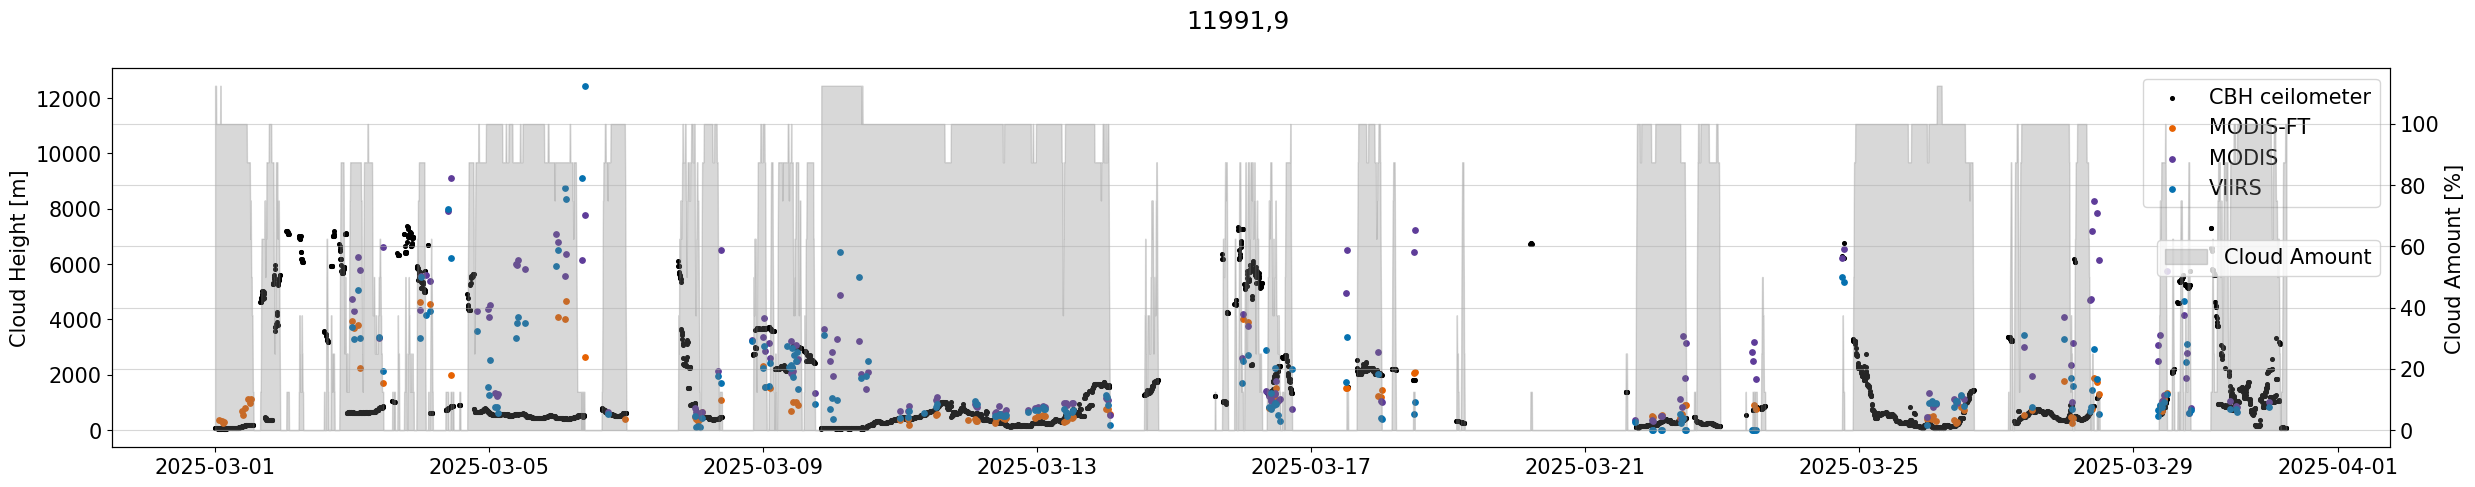

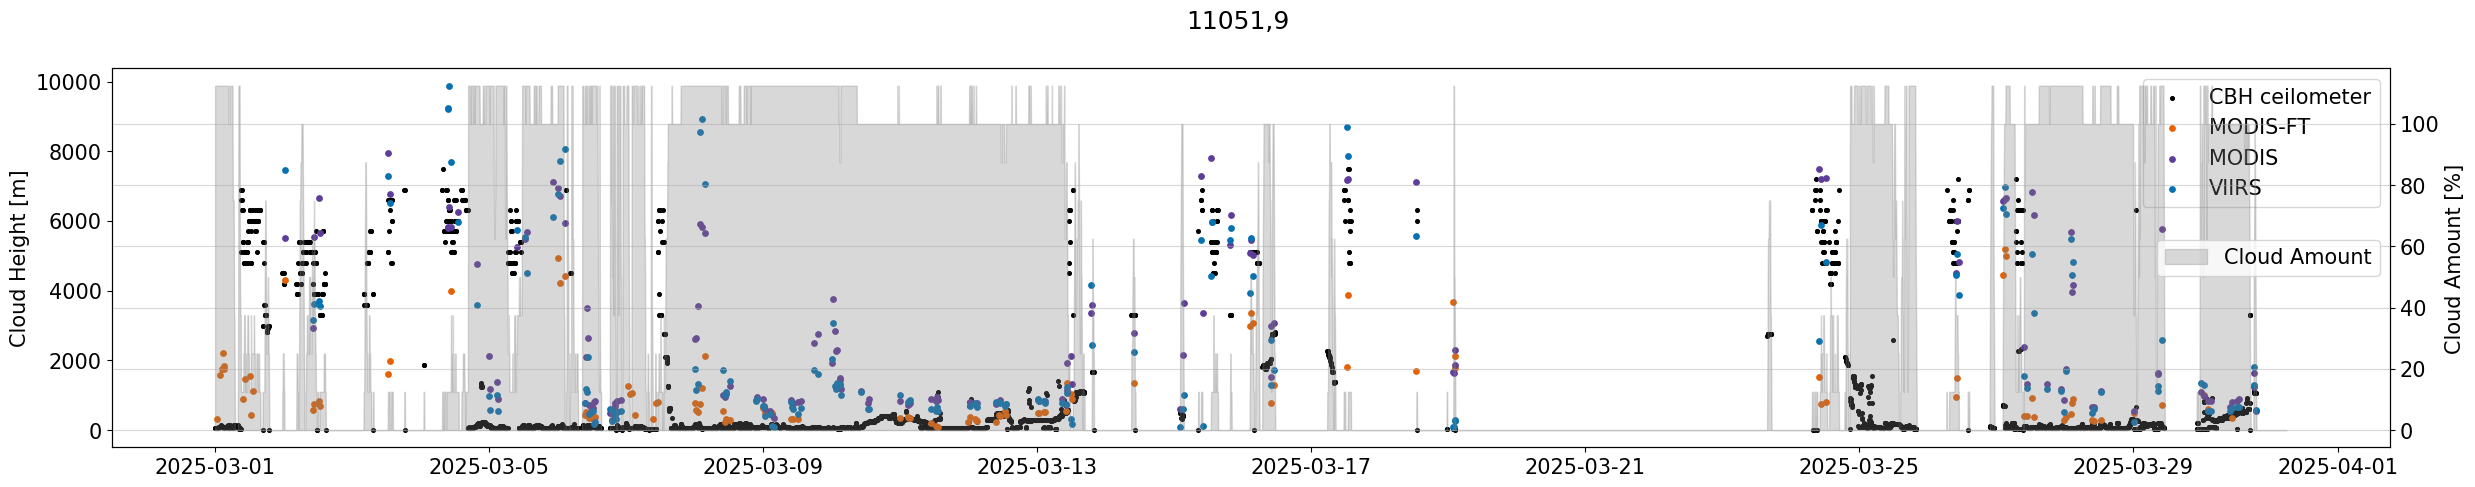

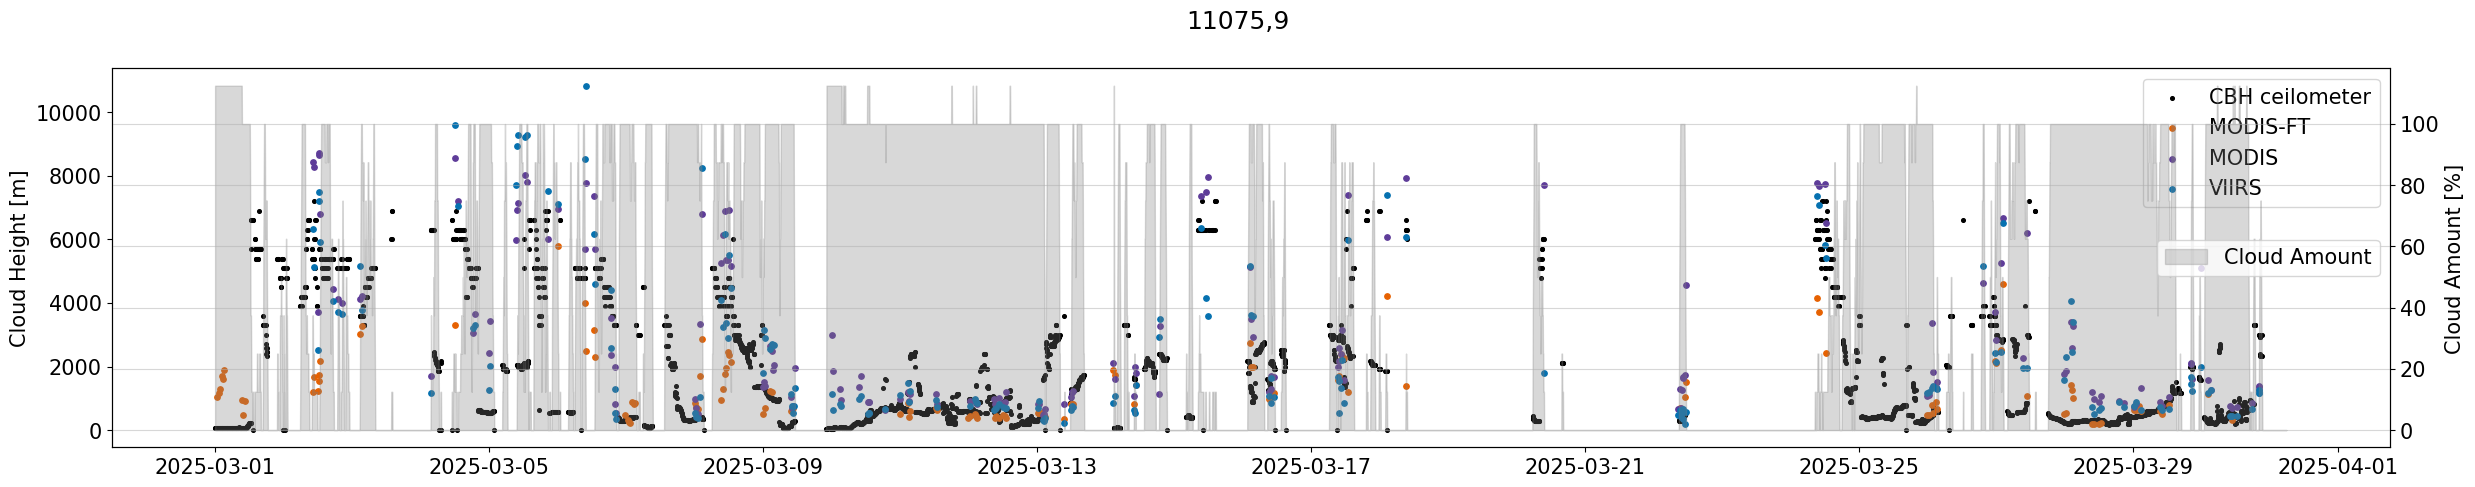

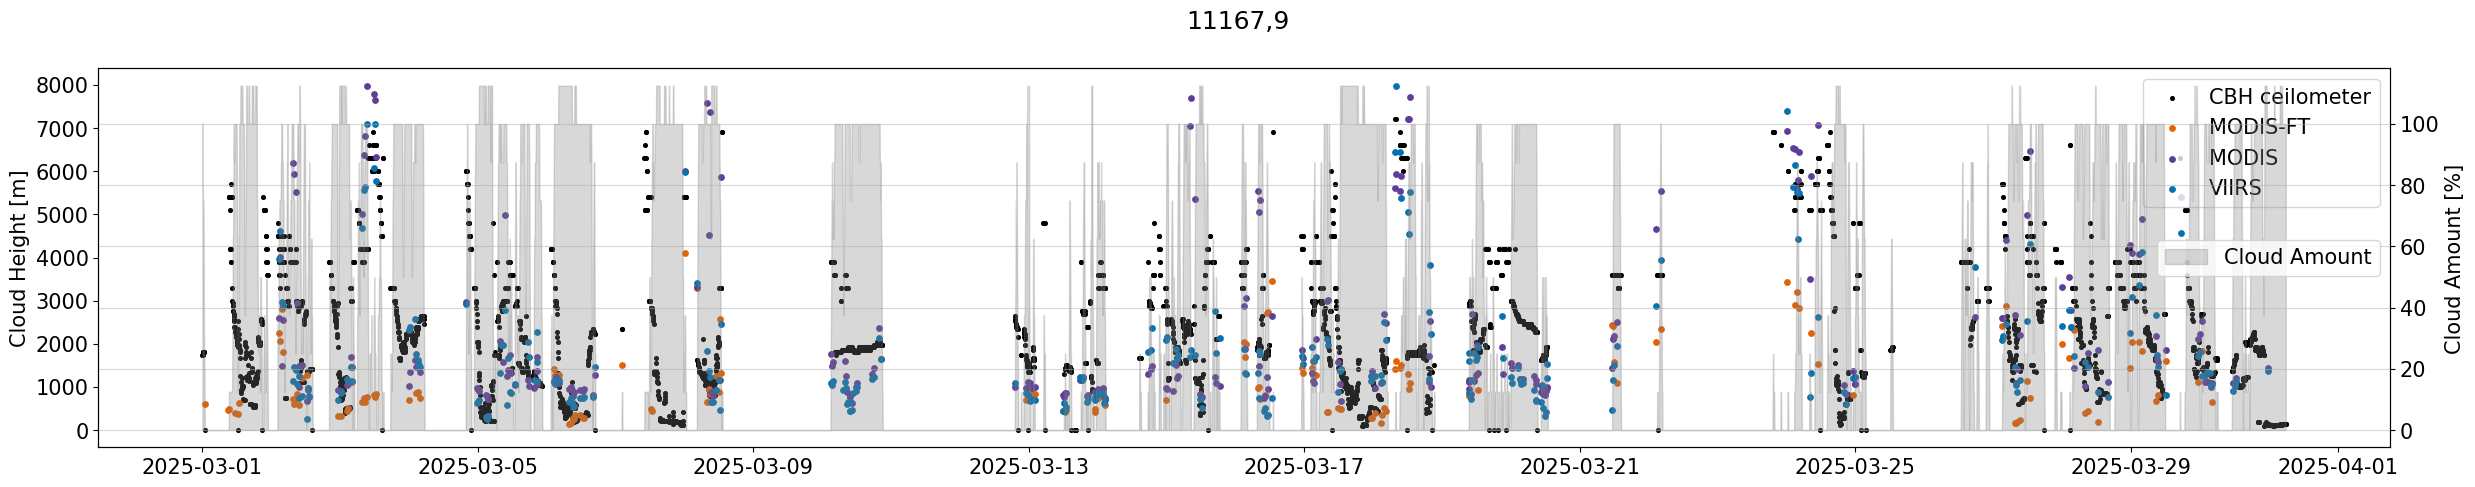

In [ ]:
station = "11991,9"  # norrkoping
# station = "11021,9" # ljungby
# station = "11167,9" # holmon
# station = "11051,9" # nordkoster
# station = "11026,9"
# station = "11072,9"
# station = "11008,9"
# station = "11072,9"
# station = "11094,9"
# station = "11167,9"
# station = "11075,9"
# station = "11191,9"
for station in ["11991,9", "11051,9", "11075,9", "11167,9"]:
    cbfile = Path(f"/home/sm_indka/data/Celiometer/CloudBase_data_{station}.csv")
    cafile = Path(f"/home/sm_indka/data/Celiometer/TotalCloudAmount_data_{station}.csv")

    # cm = CeilometerData.from_mora_file(cbfile, cafile)

    # cbfile = Path("/home/sm_indka/data/Celiometer/CloudBase_data_11002,9.csv")
    cm = CeilometerData.from_mora_file(cbfile, cafile)

    collocationfile = f"/home/sm_indka/Projects/ceilometer_validation/cm_validation/scripts/collocated_data_{station}_avg_all_5km_with_precip_finetuned.pickle"
    with open(collocationfile, "rb") as f:
        data = pickle.load(f)

    # collocationfile = f"/home/sm_indka/Projects/ceilometer_validation/cm_validation/scripts/collocated_data_aug_2025/collocated_data_{station}_avg_all_5km_with_precip_finetuned.pickle"
    # with open(collocationfile, "rb") as f:
    #     data1 = pickle.load(f)

    collocationfile1 = f"/home/sm_indka/Projects/ceilometer_validation/cm_validation/scripts/results/modis_algos/collocated_data_{station}_avg_all_5km_with_precip.pickle"
    with open(collocationfile1, "rb") as f:
        data1 = pickle.load(f)
    #
    collocationfile2 = f"/home/sm_indka/Projects/ceilometer_validation/cm_validation/scripts/results/collocated_data_{station}_avg_all_5km_with_precip.pickle"
    with open(collocationfile2, "rb") as f:
        data2 = pickle.load(f)

    plt.rcParams.update({"font.size": 15})
    fig, ax = plt.subplots(1, 1, figsize=(25, 5))
    time_threshold1 = np.datetime64("2025-03-01T00:00:00.000000000")
    time_threshold2 = np.datetime64("2025-03-31T06:00:00.000000000")

    tmask = (cm.time < time_threshold2) & (cm.time > time_threshold1)
    ax.scatter(
        cm.time[tmask], cm.cbh_agl[:, 0][tmask], c="k", s=7, label="CBH ceilometer"
    )

    SIZE = 15
    tmask_collo = (
        ((np.array(data["time"])) < time_threshold2)
        & ((np.array(data["time"])) > time_threshold1)
        & (np.array(data["cbh_cm"]) > 0)
    )
    ax.scatter(
        np.array(data["time"])[tmask_collo],
        np.array(data["cbh_sat"])[tmask_collo],
        c="#e66101",
        s=SIZE,
        label="MODIS-FT",
    )
    # ax.scatter(np.array(data["time"])[tmask_collo], np.array(data["cth"])[tmask_collo], c = "tab:blue", s = 7, label="CTH PPS")

    tmask_collo = (
        ((np.array(data1["time"])) < time_threshold2)
        & ((np.array(data1["time"])) > time_threshold1)
        & (np.array(data1["cbh_cm"]) > 0)
    )
    ax.scatter(
        np.array(data1["time"])[tmask_collo],
        np.array(data1["cbh_sat"])[tmask_collo],
        c="#5e3c99",
        s=SIZE,
        label="MODIS",
    )

    tmask_collo = (
        ((np.array(data2["time"])) < time_threshold2)
        & ((np.array(data2["time"])) > time_threshold1)
        & (np.array(data2["cbh_cm"]) > 0)
    )
    # ax.scatter(np.array(data2["time"])[tmask_collo], np.array(data2["cbh_sat"])[tmask_collo], c = "#0571b0", s = SIZE, label="VIIRS")

    ax2 = ax.twinx()
    # ax2.scatter(cm.time[tmask], cm.cloudamount[tmask], s=1, c="cyan")
    ax2.fill_between(
        cm.time[tmask],
        cm.cloudamount[tmask],
        color="gray",
        alpha=0.3,
        label="Cloud Amount",
    )
    ax2.grid("on", alpha=0.5)
    ax2.set_ylabel("Cloud Amount [%]")

    ax.set_ylabel("Cloud Height [m]")
    fig.suptitle(station)
    ax2.legend(loc="right")
    ax.legend()
    fig.tight_layout()
    fig.savefig(f"{station}_profiles.png", dpi=300)

In [ ]:
cbhfile = "/nobackup/smhid20/users/sm_indka/data/pps/export/S_NWC_CBH_noaa21_00000_20250310T0756073Z_20250310T0757319Z.nc"
ctfile = "/nobackup/smhid20/users/sm_indka/data/pps/export/S_NWC_CT_noaa21_00000_20250310T0756073Z_20250310T0757319Z.nc"

In [ ]:
cbh = xr.open_dataset(cbhfile)
ct = xr.open_dataset(ctfile)

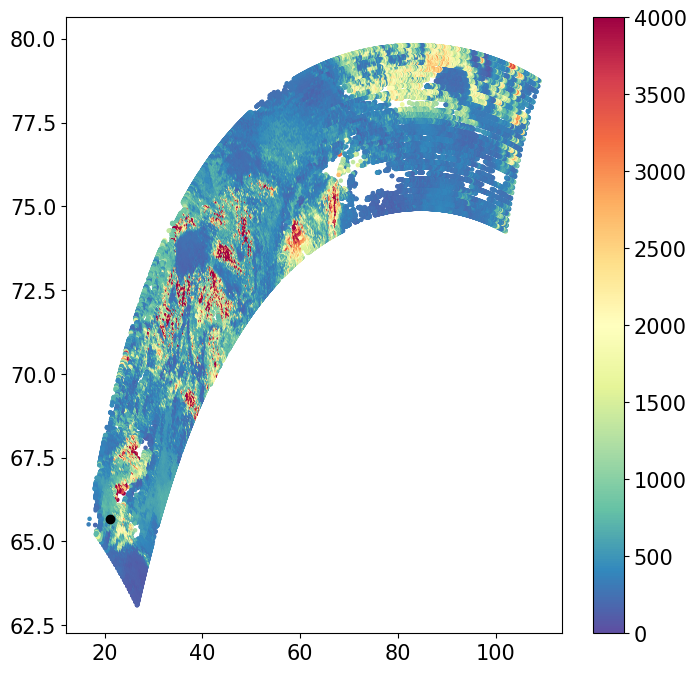

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=[8, 8])
cs = ax.scatter(
    cbh.lon.data[::10].T,
    cbh.lat.data[::10].T,
    c=cbh.cbh_alti.data[0][::10].T,
    s=5,
    vmin=0,
    vmax=4000,
    cmap="Spectral_r",
)
# ax.scatter(16.14 , 58.58, c="r")
ax.scatter(21.06, 65.67, c="k")
fig.colorbar(cs)


In [ ]:
ct

<xarray.Dataset> Size: 39MB
Dimensions:         (time: 1, nv: 2, nx: 3200, ny: 768)
Coordinates:
  * time            (time) datetime64[ns] 8B 2025-03-10T07:56:49.600000
  * nx              (nx) uint16 6kB 0 1 2 3 4 5 ... 3195 3196 3197 3198 3199
  * ny              (ny) uint16 2kB 0 1 2 3 4 5 6 ... 762 763 764 765 766 767
Dimensions without coordinates: nv
Data variables:
    time_bnds       (time, nv) datetime64[ns] 16B ...
    ct              (time, ny, nx) float32 10MB ...
    ct_conditions   (time, ny, nx) float32 10MB ...
    ct_quality      (time, ny, nx) float32 10MB ...
    ct_status_flag  (time, ny, nx) float32 10MB ...
Attributes: (12/26)
    Conventions:                CF-1.9
    institution:                SMHI
    comment:                    
    references:                 http://www.nwcsaf.org
    contact:                    NWC/PPS contact: safnwchd@aemet.es
    keywords_vocabulary:        http://gcmd.gsfc.nasa.gov/Resources/valids/gc...
    ...                         ...
    source:                     NWC/PPS version vNGI2-incr
    product_algorithm_version:  v3.1.0
    orbit_number:               0
    id:                         /home/sm_indka/data/pps/export/S_NWC_CT_noaa2...
    time_coverage_start:        20250310T0756073Z
    time_coverage_end:          20250310T0757319Z

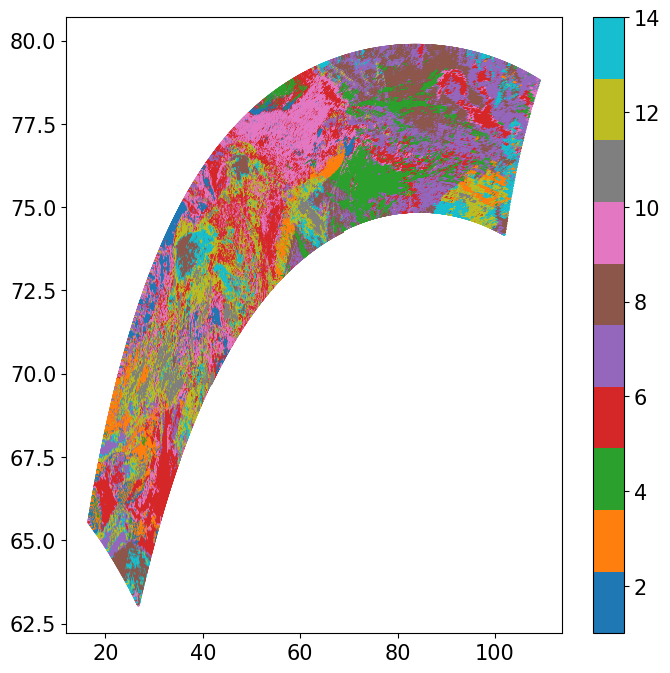

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=[8, 8])
cs = ax.scatter(
    cbh.lon.data[::5], cbh.lat.data[::5], c=ct.ct[0].data[::5], s=1, cmap="tab10"
)
fig.colorbar(cs)


In [ ]:
m = np.array(data["cbh_cm"]) > -1
np.nanmin(np.array(data["cbh_cm"])[m])

22.5

In [ ]:
ct.ct

<xarray.DataArray 'ct' (time: 1, ny: 768, nx: 3200)> Size: 10MB
[2457600 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 8B 2025-03-10T07:56:49.600000
  * nx       (nx) uint16 6kB 0 1 2 3 4 5 6 ... 3194 3195 3196 3197 3198 3199
  * ny       (ny) uint16 2kB 0 1 2 3 4 5 6 7 ... 760 761 762 763 764 765 766 767
Attributes:
    long_name:            SAFNWC PPS CT Cloud Type
    valid_range:          [ 1 15]
    ancillary_variables:  ct_conditions ct_quality ct_status_flag ct_pal
    flag_values:          [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
    flag_meanings:        Cloud-free_land Cloud-free_sea Snow_over_land Sea_i...